In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

In [ ]:
file_path = r"/Users/mua/Downloads/Superstore Sales Dataset.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (9800, 19)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
if "" in df.columns:
    df = df.drop(columns=[""])

# Convert dates using day-first format because the dataset uses dd/mm/yyyy.
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

# Keep postal code as text to avoid losing leading zeros.
df["Postal Code"] = (
    df["Postal Code"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")

# Create useful analysis columns.
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["Month Number"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (9800, 25)


,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Ship Days,Year,Month,Month Number,Year-Month,Quarter
0,0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,November,11,2017-11,Q4
1,1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,2017,November,11,2017-11,Q4
2,2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,June,6,2017-06,Q2
3,3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,October,10,2016-10,Q4
4,4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,October,10,2016-10,Q4


In [ ]:
print("Missing values")
display(df.isna().sum().sort_values(ascending=False))

print("\nData types")
display(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Missing values


Unnamed: 0       0
Region           0
Year-Month       0
Month Number     0
Month            0
Year             0
Ship Days        0
Sales            0
Product Name     0
Sub-Category     0
Category         0
Product ID       0
Postal Code      0
Row ID           0
State            0
City             0
Country          0
Segment          0
Customer Name    0
Customer ID      0
Ship Mode        0
Ship Date        0
Order Date       0
Order ID         0
Quarter          0
dtype: int64


Data types


Unnamed: 0                int64
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Ship Days                 int64
Year                      int32
Month                    object
Month Number              int32
Year-Month               object
Quarter                  object
dtype: object


Duplicate rows: 0

Date range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [ ]:
total_sales = df["Sales"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
avg_order_value = total_sales / total_orders
avg_ship_days = df["Ship Days"].mean()

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Sales",
            "Total Orders",
            "Total Customers",
            "Average Order Value",
            "Average Shipping Days",
        ],
        "Value": [
            round(total_sales, 2),
            total_orders,
            total_customers,
            round(avg_order_value, 2),
            round(avg_ship_days, 2),
        ],
    }
)

summary

,Metric,Value
0,Total Sales,2261536.78
1,Total Orders,4922.00
2,Total Customers,793.00
3,Average Order Value,459.48
4,Average Shipping Days,3.96


In [ ]:
sales_by_region = (
    df.groupby("Region", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

sales_by_category = (
    df.groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

sales_by_subcategory = (
    df.groupby("Sub-Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

sales_by_state = (
    df.groupby("State", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

top_customers = (
    df.groupby(["Customer ID", "Customer Name"], as_index=False)
    .agg(Sales=("Sales", "sum"), Orders=("Order ID", "nunique"))
    .sort_values("Sales", ascending=False)
)

display(sales_by_region)
display(sales_by_category)
display(sales_by_subcategory.head(10))
display(sales_by_state.head(10))
display(top_customers.head(10))

,Region,Sales
3,West,710219.6845
1,East,669518.7260
0,Central,492646.9132
2,South,389151.4590


,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


,Sub-Category,Sales
13,Phones,327782.4480
5,Chairs,322822.7310
14,Storage,219343.3920
16,Tables,202810.6280
3,Binders,200028.7850
11,Machines,189238.6310
0,Accessories,164186.7000
6,Copiers,146248.0940
4,Bookcases,113813.1987
1,Appliances,104618.4030


,State,Sales
3,California,446306.4635
30,New York,306361.1470
41,Texas,168572.5322
45,Washington,135206.8500
36,Pennsylvania,116276.6500
8,Florida,88436.5320
11,Illinois,79236.5170
20,Michigan,76136.0740
33,Ohio,75130.3500
44,Virginia,70636.7200


,Customer ID,Customer Name,Sales,Orders
700,SM-20320,Sean Miller,25043.050,5
741,TC-20980,Tamara Chand,19052.218,5
621,RB-19360,Raymond Buch,15117.339,6
730,TA-21385,Tom Ashbrook,14595.620,4
6,AB-10105,Adrian Barton,14473.571,10
434,KL-16645,Ken Lonsdale,14175.229,12
669,SC-20095,Sanjit Chand,14142.334,9
327,HL-15040,Hunter Lopez,12873.298,6
683,SE-20110,Sanjit Engle,12209.438,11
131,CC-12370,Christopher Conant,12129.072,5


In [ ]:
yearly_sales = (
    df.groupby("Year", as_index=False)["Sales"]
    .sum()
    .sort_values("Year")
)

monthly_sales = (
    df.groupby(["Year-Month", "Year", "Month Number"], as_index=False)["Sales"]
    .sum()
    .sort_values(["Year", "Month Number"])
)

display(yearly_sales)
display(monthly_sales.tail(12))


,Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


,Year-Month,Year,Month Number,Sales
36,2018-01,2018,1,43476.4740
37,2018-02,2018,2,19920.9974
38,2018-03,2018,3,58863.4128
39,2018-04,2018,4,35541.9101
40,2018-05,2018,5,43825.9822
41,2018-06,2018,6,48190.7277
42,2018-07,2018,7,44825.1040
43,2018-08,2018,8,62837.8480
44,2018-09,2018,9,86152.8880
45,2018-10,2018,10,77448.1312


In [ ]:
shipping_summary = (
    df.groupby("Ship Mode", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Avg_Ship_Days=("Ship Days", "mean"),
        Orders=("Order ID", "nunique"),
    )
    .sort_values("Sales", ascending=False)
)

shipping_by_region = (
    df.groupby("Region", as_index=False)
    .agg(
        Sales=("Sales", "sum"),
        Avg_Ship_Days=("Ship Days", "mean"),
    )
    .sort_values("Sales", ascending=False)
)

display(shipping_summary)
display(shipping_by_region)

,Ship Mode,Sales,Avg_Ship_Days,Orders
3,Standard Class,1.340831e+06,5.008363,2945
2,Second Class,4.499142e+05,3.249211,944
0,First Class,3.455723e+05,2.179214,772
1,Same Day,1.252190e+05,0.044610,261


,Region,Sales,Avg_Ship_Days
3,West,710219.6845,3.930255
1,East,669518.7260,3.910233
0,Central,492646.9132,4.065876
2,South,389151.4590,3.961202


In [ ]:
customer_rank = top_customers.copy().reset_index(drop=True)
customer_rank["Rank"] = customer_rank.index + 1
customer_rank["Sales Share %"] = customer_rank["Sales"] / total_sales * 100

top_10_share = customer_rank.head(10)["Sales"].sum() / total_sales * 100
top_20_share = customer_rank.head(20)["Sales"].sum() / total_sales * 100

print(f"Top 10 customer sales share: {top_10_share:.2f}%")
print(f"Top 20 customer sales share: {top_20_share:.2f}%")

Top 10 customer sales share: 6.80%
Top 20 customer sales share: 11.70%


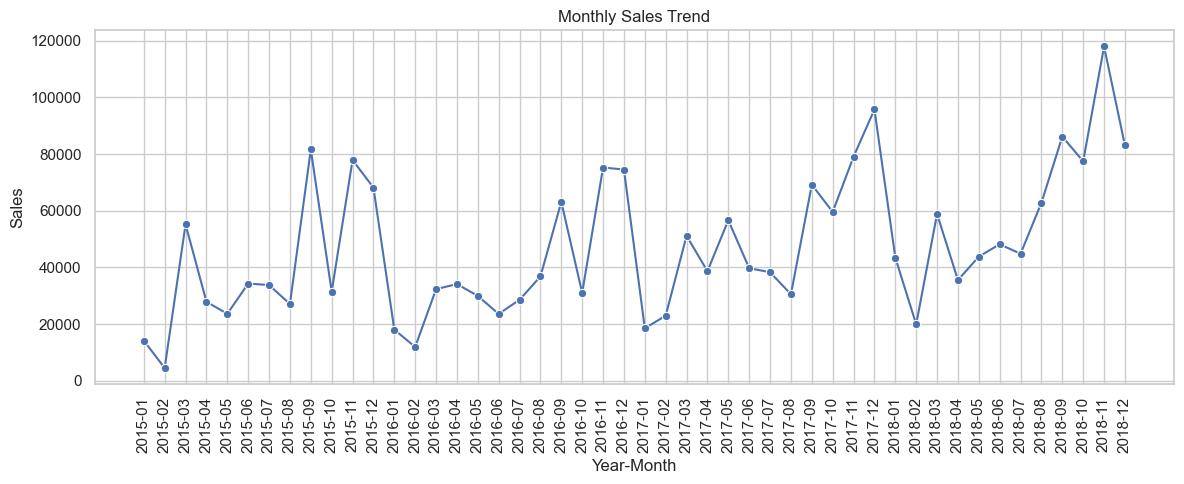

/var/folders/2q/5hxv3l6s0b58tgqty08rnp1h0000gn/T/ipykernel_9834/1327312692.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_region, x="Region", y="Sales", palette="Blues_d")


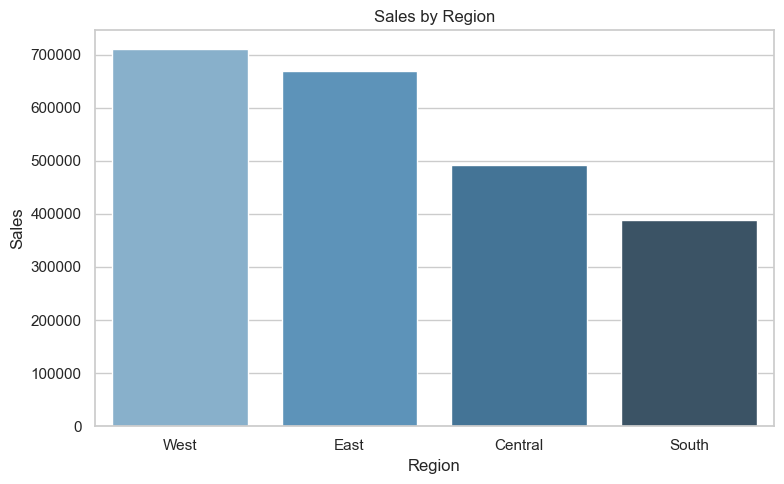

/var/folders/2q/5hxv3l6s0b58tgqty08rnp1h0000gn/T/ipykernel_9834/1327312692.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


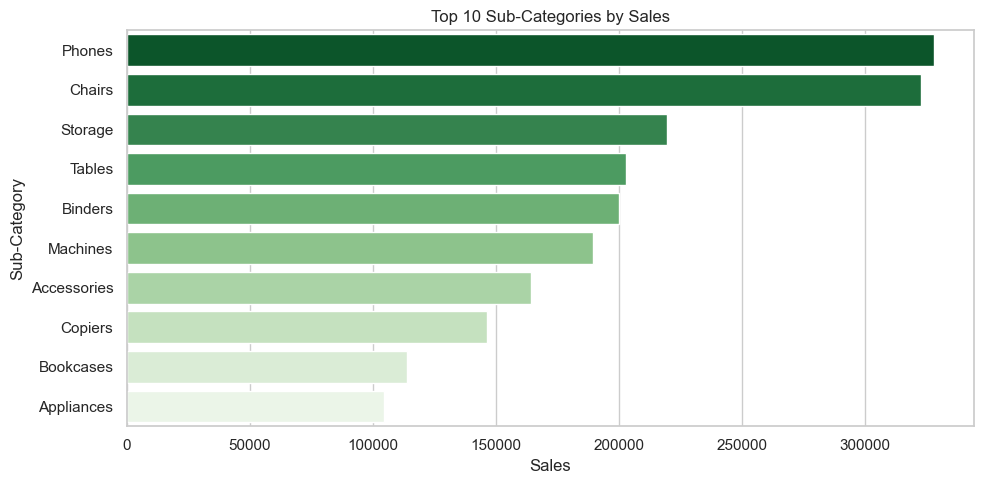

/var/folders/2q/5hxv3l6s0b58tgqty08rnp1h0000gn/T/ipykernel_9834/1327312692.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


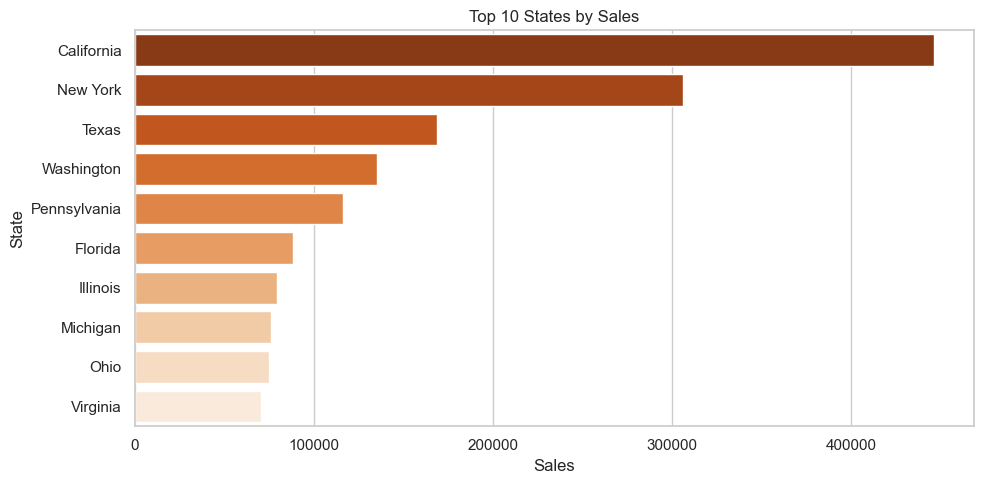

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Year-Month", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


# %%
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_region, x="Region", y="Sales", palette="Blues_d")
plt.title("Sales by Region")
plt.tight_layout()
plt.show()


# %%
plt.figure(figsize=(10, 5))
sns.barplot(
    data=sales_by_subcategory.head(10),
    x="Sales",
    y="Sub-Category",
    palette="Greens_r"
)
plt.title("Top 10 Sub-Categories by Sales")
plt.tight_layout()
plt.show()


# %%
plt.figure(figsize=(10, 5))
sns.barplot(
    data=sales_by_state.head(10),
    x="Sales",
    y="State",
    palette="Oranges_r"
)
plt.title("Top 10 States by Sales")
plt.tight_layout()
plt.show()

In [12]:
output_path = r"/Users/mua/Downloads/Superstore_Sales_Cleaned.csv"
df.to_csv(output_path, index=False)
print("Cleaned file saved to:", output_path)


Cleaned file saved to: /Users/mua/Downloads/Superstore_Sales_Cleaned.csv


In [ ]:
region_sales = df.groupby("Region", as_index=False)["Sales"].sum().sort_values("Sales", ascending=False)
print(region_sales.head(1))
